<a href="https://colab.research.google.com/github/lfernandez2021/ECE570_TermProject/blob/main/Code_Deliverable_Term_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ECE 57000 Artificial Intelligence - Course Project
#Track 1 Tiny Reproductions - The Art of Scientific Distillation


#Part 0 - Data loading


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
file_path = '/content/drive/MyDrive/Colab Notebooks/01_ECE_570/02 Course Project/Data/Task7/task7_X_train.npy'
X_train = np.load(file_path, allow_pickle=True) # Use allow_pickle=True if the file contains Python objects

file_path = '/content/drive/MyDrive/Colab Notebooks/01_ECE_570/02 Course Project/Data/Task7/task7_y_train.npy'
y_train = np.load(file_path, allow_pickle=True) # Use allow_pickle=True if the file contains Python objects

file_path = '/content/drive/MyDrive/Colab Notebooks/01_ECE_570/02 Course Project/Data/Task7/task7_X_test.npy'
X_test = np.load(file_path, allow_pickle=True) # Use allow_pickle=True if the file contains Python objects

file_path = '/content/drive/MyDrive/Colab Notebooks/01_ECE_570/02 Course Project/Data/Task7/task7_y_test.npy'
y_test = np.load(file_path, allow_pickle=True) # Use allow_pickle=True if the file contains Python objects


In [ ]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Total number of elements in X_train: {X_train.size}")
print(f"Number of samples in X_train: {len(X_train)}",'\n')

print(f"Shape of y_train: {y_train.shape}")
print(f"Total number of elements in y_train: {y_train.size}")
print(f"Number of samples in y_train: {len(y_train)}",'\n')

print(f"Shape of X_test: {X_test.shape}")
print(f"Total number of elements in X_test: {X_test.size}")
print(f"Number of samples in X_test: {len(X_test)}",'\n')

print(f"Shape of y_test: {y_test.shape}")
print(f"Total number of elements in y_test: {y_test.size}")
print(f"Number of samples in y_test: {len(y_test)}",'\n')

Shape of X_train: (4138, 224, 224, 3)
Total number of elements in X_train: 622884864
Number of samples in X_train: 4138 

Shape of y_train: (4138, 4)
Total number of elements in y_train: 16552
Number of samples in y_train: 4138 

Shape of X_test: (498, 224, 224, 3)
Total number of elements in X_test: 74962944
Number of samples in X_test: 498 

Shape of y_test: (498, 4)
Total number of elements in y_test: 1992
Number of samples in y_test: 498 



In [ ]:
print(f'The max of training data is {X_train.max():.2f} and the min is {X_train.min():.2f}.')
print(f'The max of training label data is {y_train.max():.2f} and the min is {y_train.min():.2f}.')


print(f'The max of testing data is {X_test.max():.2f} and the min is {X_test.min():.2f}.')
print(f'The max of testing label data is {y_test.max():.2f} and the min is {y_test.min():.2f}.')


The max of training data is 151.06 and the min is -123.68.
The max of training label data is 1.00 and the min is 0.00.
The max of testing data is 151.06 and the min is -123.68.
The max of testing label data is 1.00 and the min is 0.00.


In [ ]:
a = y_train[1]
b = y_train[1000]
c = y_train[2500]
d = y_train[4000]
print(a, '\n', b, '\n', c, '\n' , d)

[1. 0. 0. 0.] 
 [0. 1. 0. 0.] 
 [0. 0. 1. 0.] 
 [0. 0. 0. 1.]


In [ ]:
import time
import builtins
from typing import List, Dict
import torch
import torchvision
import torchvision.models as models
import torch.nn as nn
import torchvision.transforms.v2 as transforms
import torch.optim as optim
from torchvision.ops import Permute


In [ ]:
# Dataset preprocessing and transformation
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

mean = torch.tensor(mean).reshape(1, 3, 1, 1)
std  = torch.tensor(std).reshape(1, 3, 1, 1)

min_val = X_train.min()
max_val = X_train.max()
difference = max_val - min_val

X_train_sc = (X_train - min_val) / difference
X_test_sc = (X_test - min_val) / difference

def transform(dataset, mean, std):
    dataset = torch.from_numpy(dataset).float()
    dataset = dataset.permute(0, 3, 1, 2)
    dataset = (dataset - mean) / std
    return dataset


X_train_t = transform(X_train_sc, mean, std)
X_test_t = transform(X_test, mean, std)




###

y_train_tensor = torch.from_numpy(y_train).float()
y_train_indices = y_train_tensor.argmax(dim=1).long()  # shape [N], values in [0,3]



y_test_tensor = torch.from_numpy(y_test).float()
y_test_indices = y_test_tensor.argmax(dim=1).long()


from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_t, y_train_indices)
test_dataset  = TensorDataset(X_test_t, y_test_indices)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# from torchvision.models import resnet18, ResNet18_Weights
# import torch.nn as nn

# resnet18_model = resnet18(weights=ResNet18_Weights.DEFAULT)
# resnet18_model.fc = nn.Linear(resnet18_model.fc.in_features, 4)  # 4 classes
# resnet18_model = resnet18_model.to(device)


In [ ]:
def train(model: nn.Module,
          loss_fn: nn.modules.loss._Loss,
          optimizer: torch.optim.Optimizer,
          train_loader: torch.utils.data.DataLoader,
          epoch: int=0)-> List:
    # ----------- <Your code> ---------------

  model.train()
  train_loss = []
  train_counter = []
  train_losses = []

  for batch_idx, (images, targets) in enumerate(train_loader):

    images = images.to(device)
    targets = targets.to(device)

    optimizer.zero_grad()
    output = model(images)
    loss = loss_fn(output, targets)
    loss.backward()
    optimizer.step()

    train_loss.append(loss.item())

    if batch_idx % 100 == 0:
      print(f'Epoch {epoch}: [{batch_idx*len(images)}/{len(train_loader.dataset)}] Loss: {loss.item():.3f}')

    # ----------- <End Your code> ---------------
  assert len(train_loss) == len(train_loader)
  return train_loss

def test(model: nn.Module,
         loss_fn: nn.modules.loss._Loss,
         test_loader: torch.utils.data.DataLoader,
         epoch: int=0)-> Dict:
    # ----------- <Your code> ---------------

  model.eval()

  test_loss = 0
  correct = 0
  test_losses = []
  test_stat = {}
  total_num = []

  with torch.no_grad():
    for images, targets in test_loader:

      images = images.to(device)
      targets = targets.to(device)

      output = model(images)
      test_loss += loss_fn(output, targets).item()*images.size(0)

      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(targets.data.view_as(pred)).sum()

      total_num.append(pred)

  total_num = torch.cat(total_num)
  total_samples = len(total_num)
  test_loss /= len(test_loader.dataset)
  accuracy = correct / len(test_loader.dataset)
  test_losses.append(test_loss)

  test_stat = {"loss": test_loss, "accuracy": accuracy, "prediction": total_num}

  print(f"Test result on epoch {epoch}: total sample: {total_samples}, Avg loss: {test_stat['loss']:.3f}, Acc: {100*test_stat['accuracy']:.3f}%")

In [ ]:
# Importing, training, and testing ResNet 18
start = time.time()
max_epoch = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from torchvision.models import resnet18, ResNet18_Weights

resnet18 = resnet18(weights=ResNet18_Weights.DEFAULT)
resnet18 = resnet18.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet18.parameters(), lr=0.001, momentum=0.9)

for epoch in builtins.range(1, max_epoch+1):
  train(resnet18, criterion, optimizer, train_loader, epoch)

test(resnet18, criterion, test_loader, epoch)
end = time.time()
print(f'Finished Training after {end-start} s ')

Epoch 1: [0/4138] Loss: 10.222
Epoch 1: [1600/4138] Loss: 1.022
Epoch 1: [3200/4138] Loss: 1.322
Epoch 2: [0/4138] Loss: 0.880
Epoch 2: [1600/4138] Loss: 0.614
Epoch 2: [3200/4138] Loss: 0.478
Epoch 3: [0/4138] Loss: 0.326
Epoch 3: [1600/4138] Loss: 0.380
Epoch 3: [3200/4138] Loss: 0.460
Epoch 4: [0/4138] Loss: 0.254
Epoch 4: [1600/4138] Loss: 0.333
Epoch 4: [3200/4138] Loss: 0.131
Epoch 5: [0/4138] Loss: 0.188
Epoch 5: [1600/4138] Loss: 0.227
Epoch 5: [3200/4138] Loss: 0.285
Epoch 6: [0/4138] Loss: 0.017
Epoch 6: [1600/4138] Loss: 0.055
Epoch 6: [3200/4138] Loss: 0.056
Epoch 7: [0/4138] Loss: 0.050
Epoch 7: [1600/4138] Loss: 0.173
Epoch 7: [3200/4138] Loss: 0.018
Epoch 8: [0/4138] Loss: 0.019
Epoch 8: [1600/4138] Loss: 0.155
Epoch 8: [3200/4138] Loss: 0.020
Epoch 9: [0/4138] Loss: 0.178
Epoch 9: [1600/4138] Loss: 0.068
Epoch 9: [3200/4138] Loss: 0.015
Epoch 10: [0/4138] Loss: 0.057
Epoch 10: [1600/4138] Loss: 0.020
Epoch 10: [3200/4138] Loss: 0.005
Test result on epoch 10: total sampl

TypeError: Invalid shape (3, 224, 224) for image data

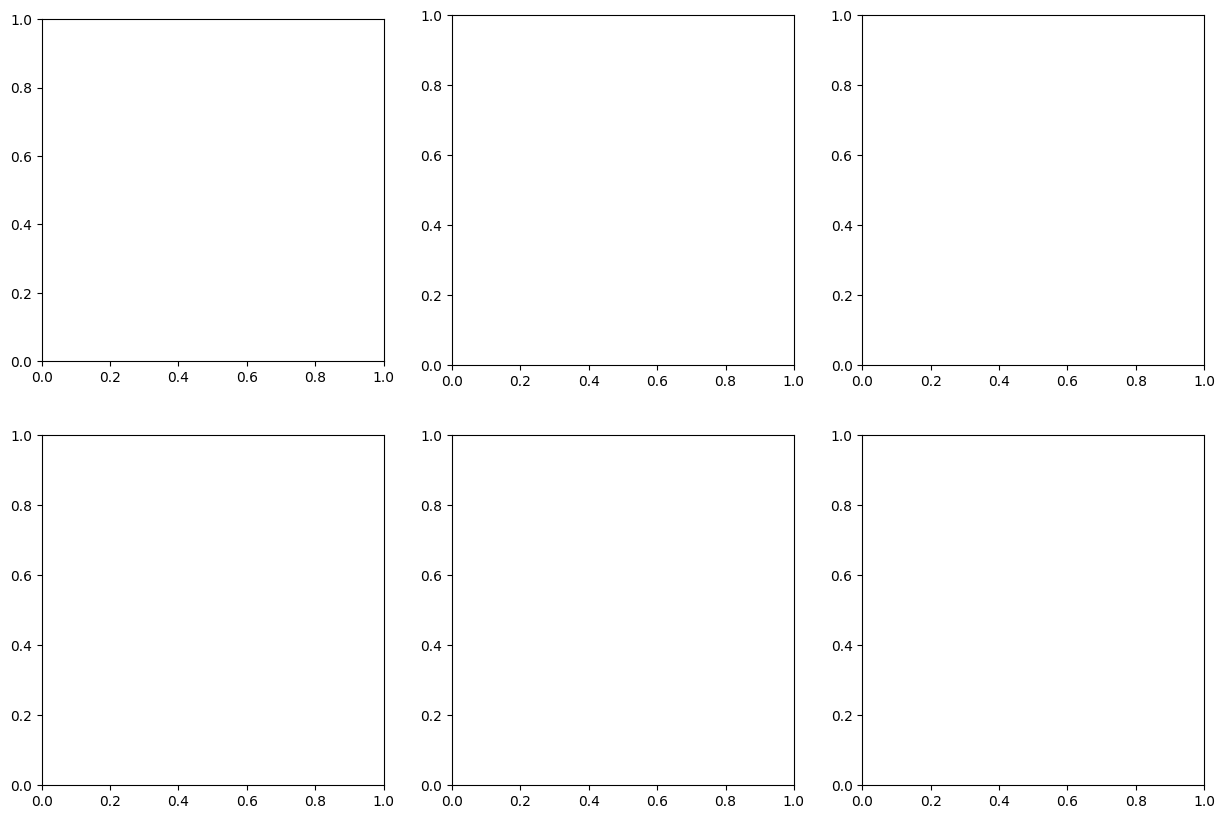

In [ ]:
sample_image_1 = X_train_t[0]
sample_image_2 = X_train_t[50]
sample_image_3 = X_train_t[100]
sample_image_4 = X_train_t[150]
sample_image_5 = X_train_t[280]
sample_image_6 = X_train_t[350]

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 3. Flatten the axes array to iterate through it easily with a single index
axes_flat = axes.flatten()

# List of your sample images
images = [sample_image_1, sample_image_2, sample_image_3, sample_image_4,
          sample_image_5, sample_image_6]
titles = ["Sample Image 1", "Sample Image 2", "Sample Image 3",
          "Sample Image 4", "Sample Image 5", "Sample Image 6"]

for i in builtins.range(6):
    axes_flat[i].imshow(images[i])
    axes_flat[i].set_title(titles[i])
    axes_flat[i].axis('off')  # Hide the pixel ticks for a cleaner look

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sample_image = X_train[0]

X_train_min = X_train.min()
X_train_max = X_train.max()
X_train_range = X_train_max - X_train_min

print(X_train_min, X_train_max, X_train_range)

plt.imshow((sample_image - X_train_min)/X_train_range)
plt.title("Visualizing 224x224 RGB Image")
plt.axis('off') # Hide pixel ticks
plt.show()